In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv to Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv


In [4]:
df = pd.read_csv(
    "Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv"
)

In [5]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [6]:
df.isnull().sum()

,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


In [7]:
missing_percent = (
    df.isnull().sum()
    / len(df)
) * 100

missing_percent

,0
transaction_id,0.00
user_id,0.00
age,0.00
gender,0.00
daily_screen_time_hours,0.00
social_media_hours,0.00
gaming_hours,0.00
work_study_hours,0.00
sleep_hours,0.00
notifications_per_day,0.00


In [13]:
#Numerical Columns
numeric_cols = df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [14]:
#Categorical Columns
cat_cols = df.select_dtypes(
    exclude=np.number
).columns

for col in cat_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [15]:
df.isnull().sum()

,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


In [16]:
#Check:
df.duplicated().sum()

#Remove:

df = df.drop_duplicates()

#Verify:

df.duplicated().sum()

np.int64(0)

In [17]:
df.drop(
    columns=[
        'transaction_id',
        'user_id'
    ],
    inplace=True
)

In [18]:
df.head()

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,Moderate,0
1,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,Moderate,0
2,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [19]:
df['gender'].unique()

array(['Male', 'Other', 'Female'], dtype=object)

In [20]:
encoder = LabelEncoder()

df['gender'] = encoder.fit_transform(
    df['gender']
)

In [21]:
df['addicted_label'].unique()

array([0, 1])

In [22]:
df['addicted_label'] = encoder.fit_transform(
    df['addicted_label']
)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      7500 non-null   int64  
 1   gender                   7500 non-null   int64  
 2   daily_screen_time_hours  7500 non-null   float64
 3   social_media_hours       7500 non-null   float64
 4   gaming_hours             7500 non-null   float64
 5   work_study_hours         7500 non-null   float64
 6   sleep_hours              7500 non-null   float64
 7   notifications_per_day    7500 non-null   int64  
 8   app_opens_per_day        7500 non-null   int64  
 9   weekend_screen_time      7500 non-null   float64
 10  stress_level             7500 non-null   object 
 11  academic_work_impact     7500 non-null   object 
 12  addiction_level          7500 non-null   object 
 13  addicted_label           7500 non-null   int64  
dtypes: float64(6), int64(5),

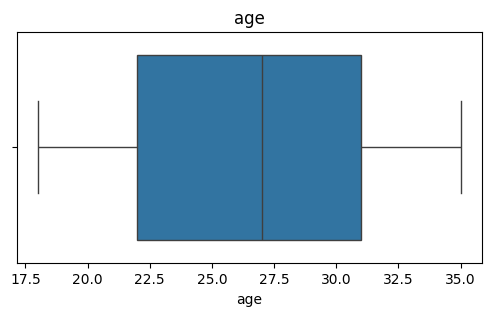

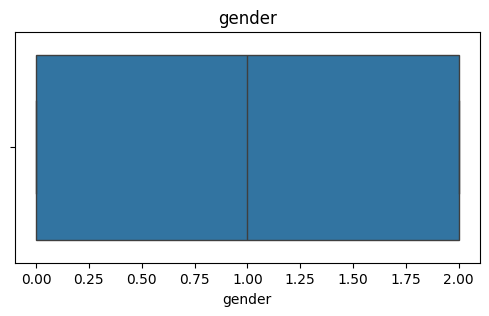

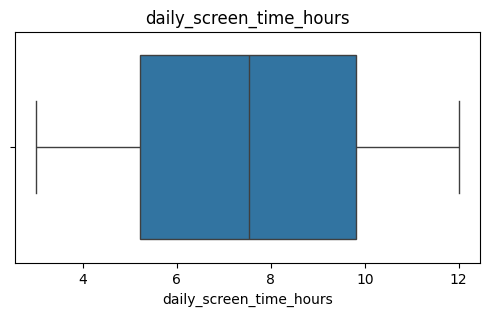

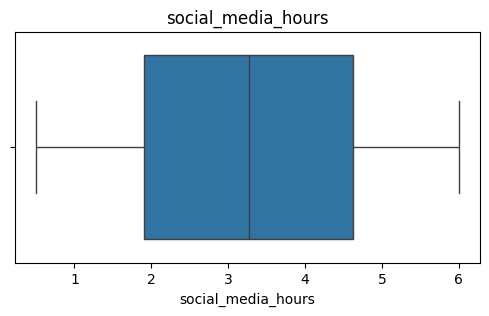

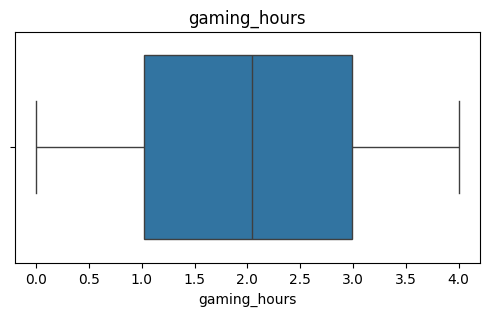

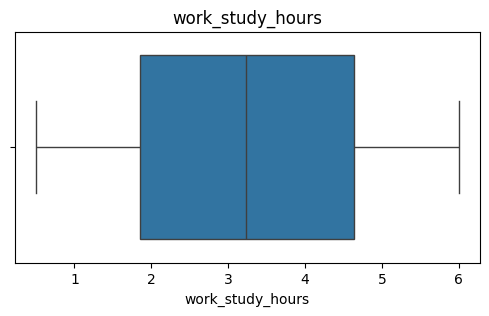

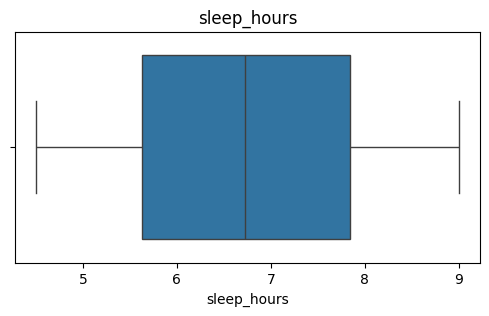

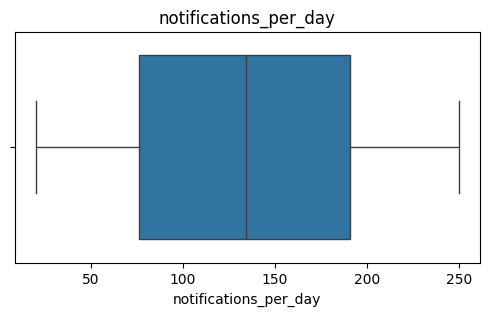

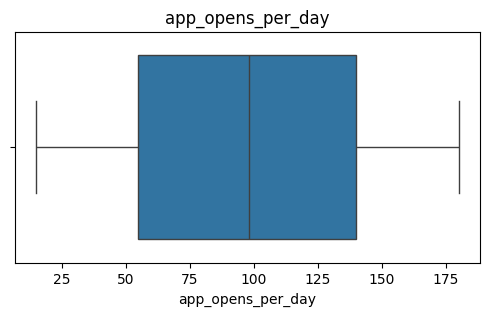

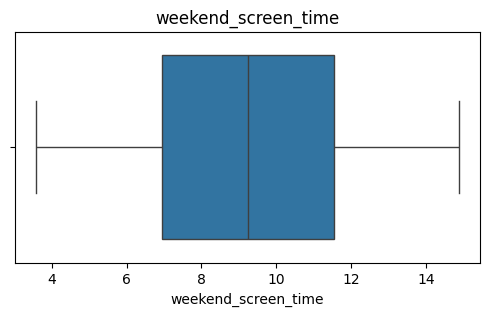

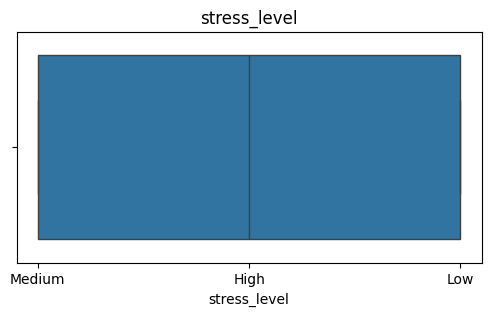

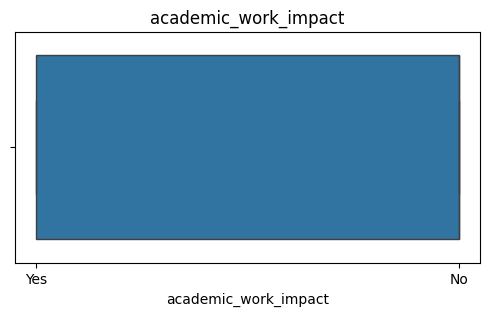

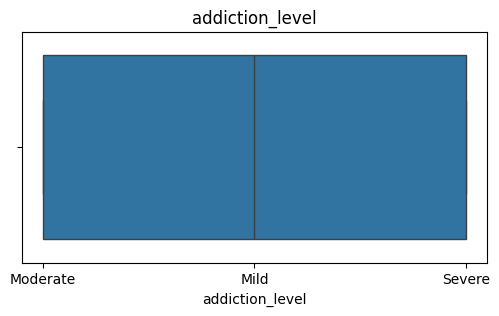

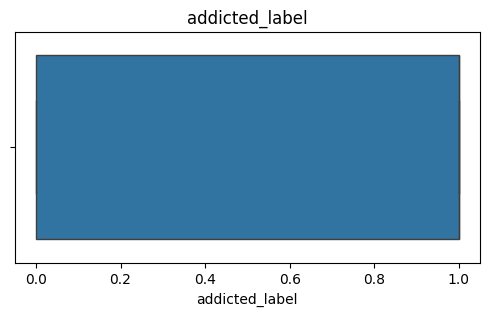

In [24]:
for col in df.columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

In [26]:
def remove_outliers(df,column):

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR

    upper = Q3 + 1.5*IQR

    return df[
        (df[column]>=lower)
        &
        (df[column]<=upper)
    ]

In [27]:
for col in numeric_cols:

    if col in df.columns:

        df = remove_outliers(
            df,
            col
        )

In [28]:
df.shape

(7500, 14)

In [29]:
df[
    'weekend_usage_difference'
] = (
    df['weekend_screen_time']
    -
    df['daily_screen_time_hours']
)

In [30]:
df[
    'sleep_deficit'
] = (
    8
    -
    df['sleep_hours']
)

In [31]:
df[
    'notification_intensity'
] = (
    df['notifications_per_day']
    /
    df['daily_screen_time_hours']
)

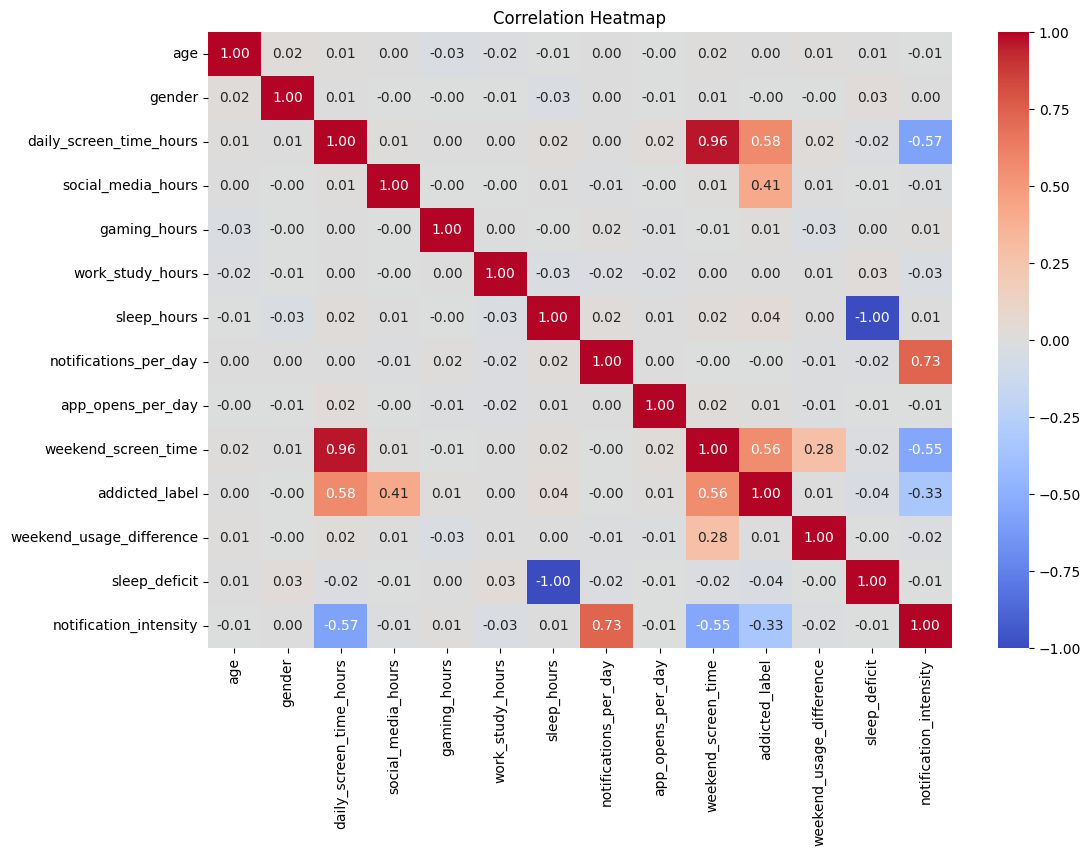

In [34]:
# Select only numeric columns for correlation

numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [35]:
import os

os.makedirs(
    "processed_data",
    exist_ok=True
)

In [36]:
df.to_csv(
    "processed_data/cleaned_data.csv",
    index=False
)

In [37]:
from google.colab import files

files.download(
    "processed_data/cleaned_data.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Raw Dataset
      ↓
Notebook 1
Dataset Understanding
      ↓
Notebook 2
Cleaning + Feature Engineering
      ↓
cleaned_data.csv
      ↓
Notebook 3
Exploratory Data Analysis